# Trace Plotting Development

Goal: Create publication-quality trace plots with:
- Proper DF/F calculation (sensor-specific decay parameters)
- Accurate scale bars
- Smart cell selection (exclude bad traces)
- Raw and DF/F comparison
- Flexible percentile filtering

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.ndimage import percentile_filter

# Set style
plt.style.use('dark_background')
sns.set_palette("husl")
%matplotlib inline

## 1. Load Data

In [2]:
# Path to your suite2p directory
suite2p_path = Path(r"\\rbo-s1\S1_DATA\lbm\kbarber\2025-11-04-mk311\suite2p")
merged_path = suite2p_path / "merged"

# Load consolidated data
print("Loading data...")
ops = np.load(merged_path / "ops.npy", allow_pickle=True).item()
stat = np.load(merged_path / "stat.npy", allow_pickle=True)
iscell = np.load(merged_path / "iscell.npy")
F = np.load(merged_path / "F.npy")
Fneu = np.load(merged_path / "Fneu.npy")
spks = np.load(merged_path / "spks.npy")

# Get accepted cells
accepted_mask = iscell[:, 0] == 1
F_accepted = F[accepted_mask]
Fneu_accepted = Fneu[accepted_mask]
spks_accepted = spks[accepted_mask]
stat_accepted = stat[accepted_mask]

# Get frame rate
fs = ops.get('fs', 30.0)
print(f"Frame rate: {fs} Hz")
print(f"Total accepted cells: {F_accepted.shape[0]}")
print(f"Total frames: {F_accepted.shape[1]}")
print(f"Duration: {F_accepted.shape[1] / fs / 60:.1f} minutes")

Loading data...
Frame rate: 17.07249604677249 Hz
Total accepted cells: 6507
Total frames: 58825
Duration: 57.4 minutes


## 2. DF/F Calculation Functions

In [4]:
def compute_dff(
    F,
    Fneu,
    neucoeff=0.7,
    baseline_method='percentile_filter',
    percentile=8,
    window_size=None,
    fs=17,
    tau_decay=1.3,  # GCaMP decay time constant in seconds
):
    """
    Compute DF/F with multiple baseline estimation methods.

    Parameters
    ----------
    F : ndarray (n_cells, n_frames)
        Raw fluorescence traces
    Fneu : ndarray (n_cells, n_frames)
        Neuropil fluorescence
    neucoeff : float
        Neuropil coefficient (default 0.7)
    baseline_method : str
        'percentile_filter' - Rolling percentile (recommended)
        'percentile_global' - Global percentile across time
        'robust_minimum' - Robust minimum using low percentile
    percentile : int
        Percentile for baseline (8-20 typical)
    window_size : int or None
        Window size in frames. If None, computed from tau_decay
    fs : float
        Frame rate in Hz
    tau_decay : float
        Sensor decay time constant in seconds (GCaMP6s ~2s, GCaMP6f ~0.4s)

    Returns
    -------
    dff : ndarray
        DF/F traces
    F0 : ndarray
        Baseline fluorescence
    """
    # Neuropil correction
    F_corrected = F - neucoeff * Fneu

    # Auto-compute window size based on sensor decay if not provided
    if window_size is None:
        # Use ~10x the decay time constant
        window_size = int(10 * tau_decay * fs)
        print(f"Auto-computed window size: {window_size} frames ({window_size/fs:.1f}s) based on tau={tau_decay}s")

    if baseline_method == 'percentile_filter':
        # Rolling percentile - best for slow drifts
        F0 = percentile_filter(F_corrected, percentile, size=(1, window_size), mode='nearest')

    elif baseline_method == 'percentile_global':
        # Global percentile - simple but may miss drift
        F0 = np.percentile(F_corrected, percentile, axis=1, keepdims=True)

    elif baseline_method == 'robust_minimum':
        # Robust minimum - use lowest X% of values
        n_samples = int(F_corrected.shape[1] * (percentile / 100))
        F0 = np.mean(np.partition(F_corrected, n_samples, axis=1)[:, :n_samples], axis=1, keepdims=True)

    else:
        raise ValueError(f"Unknown baseline method: {baseline_method}")

    # Compute DF/F with numerical stability
    dff = (F_corrected - F0) / (F0 + 1e-6)

    return dff, F0

In [5]:
def filter_good_cells(
    dff,
    min_dff_range=0.02,   # Minimum 2% DF/F range (very permissive)
    max_dff_range=10.0,   # Maximum 1000% DF/F (very permissive)
    max_noise_level=2.0,  # Maximum noise - permissive for noisy data
    min_activity_rate=0.0001,  # Minimal activity requirement
):
    """
    Filter out truly bad cells while being robust to noisy in vivo data.

    Designed to only exclude: dead cells, extremely noisy traces, or saturated pixels.
    Most cells should pass these permissive filters.

    Returns
    -------
    good_mask : ndarray (bool)
        Boolean mask of good cells
    metrics : dict
        Quality metrics for each cell
    """
    n_cells = dff.shape[0]

    # Compute metrics
    dff_range = np.ptp(dff, axis=1)
    dff_std = np.std(dff, axis=1)

    # Noise estimate (MAD of first derivative)
    noise = np.median(np.abs(np.diff(dff, axis=1)), axis=1) / 0.6745

    # Activity rate (fraction of frames above 2 std)
    activity_rate = np.mean(dff > 2 * dff_std[:, np.newaxis], axis=1)

    # Very permissive filters - only exclude truly bad cells
    good_mask = (
        (dff_range >= min_dff_range) &
        (dff_range <= max_dff_range) &
        (noise <= max_noise_level) &
        (activity_rate >= min_activity_rate)
    )

    metrics = {
        'dff_range': dff_range,
        'dff_std': dff_std,
        'noise': noise,
        'activity_rate': activity_rate,
    }

    print(f"Filtered cells: {good_mask.sum()}/{n_cells} passed quality checks ({100*good_mask.sum()/n_cells:.1f}%)")
    print(f"  Failed dff_range: {np.sum((dff_range < min_dff_range) | (dff_range > max_dff_range))}")
    print(f"  Failed noise: {np.sum(noise > max_noise_level)}")
    print(f"  Failed activity: {np.sum(activity_rate < min_activity_rate)}")

    return good_mask, metrics

## 3. Compute DF/F with Different Methods

In [6]:
# Test different baseline methods
print("Computing DF/F with percentile filter (recommended)...")
dff_pf, F0_pf = compute_dff(
    F_accepted,
    Fneu_accepted,
    baseline_method='percentile_filter',
    percentile=8,
    fs=fs,
    tau_decay=1.3,  # GCaMP6s
)

print("\nComputing DF/F with global percentile...")
dff_global, F0_global = compute_dff(
    F_accepted,
    Fneu_accepted,
    baseline_method='percentile_global',
    percentile=20,
    fs=fs,
)

Computing DF/F with percentile filter (recommended)...
Auto-computed window size: 221 frames (12.9s) based on tau=1.3s

Computing DF/F with global percentile...
Auto-computed window size: 221 frames (12.9s) based on tau=1.3s


In [7]:
# Filter for good cells - use permissive settings for noisy in vivo data
print("\nFiltering for high-quality cells...")
good_mask, metrics = filter_good_cells(dff_pf)

# Select good cells
dff_good = dff_pf[good_mask]
F_good = F_accepted[good_mask]
Fneu_good = Fneu_accepted[good_mask]
spks_good = spks_accepted[good_mask]

print(f"\nSelected {dff_good.shape[0]} high-quality cells for plotting")


Filtering for high-quality cells...
Filtered cells: 2746/6507 passed quality checks (42.2%)
  Failed dff_range: 3731
  Failed noise: 1784
  Failed activity: 135

Selected 2746 high-quality cells for plotting


## 4. Quality Metrics Visualization

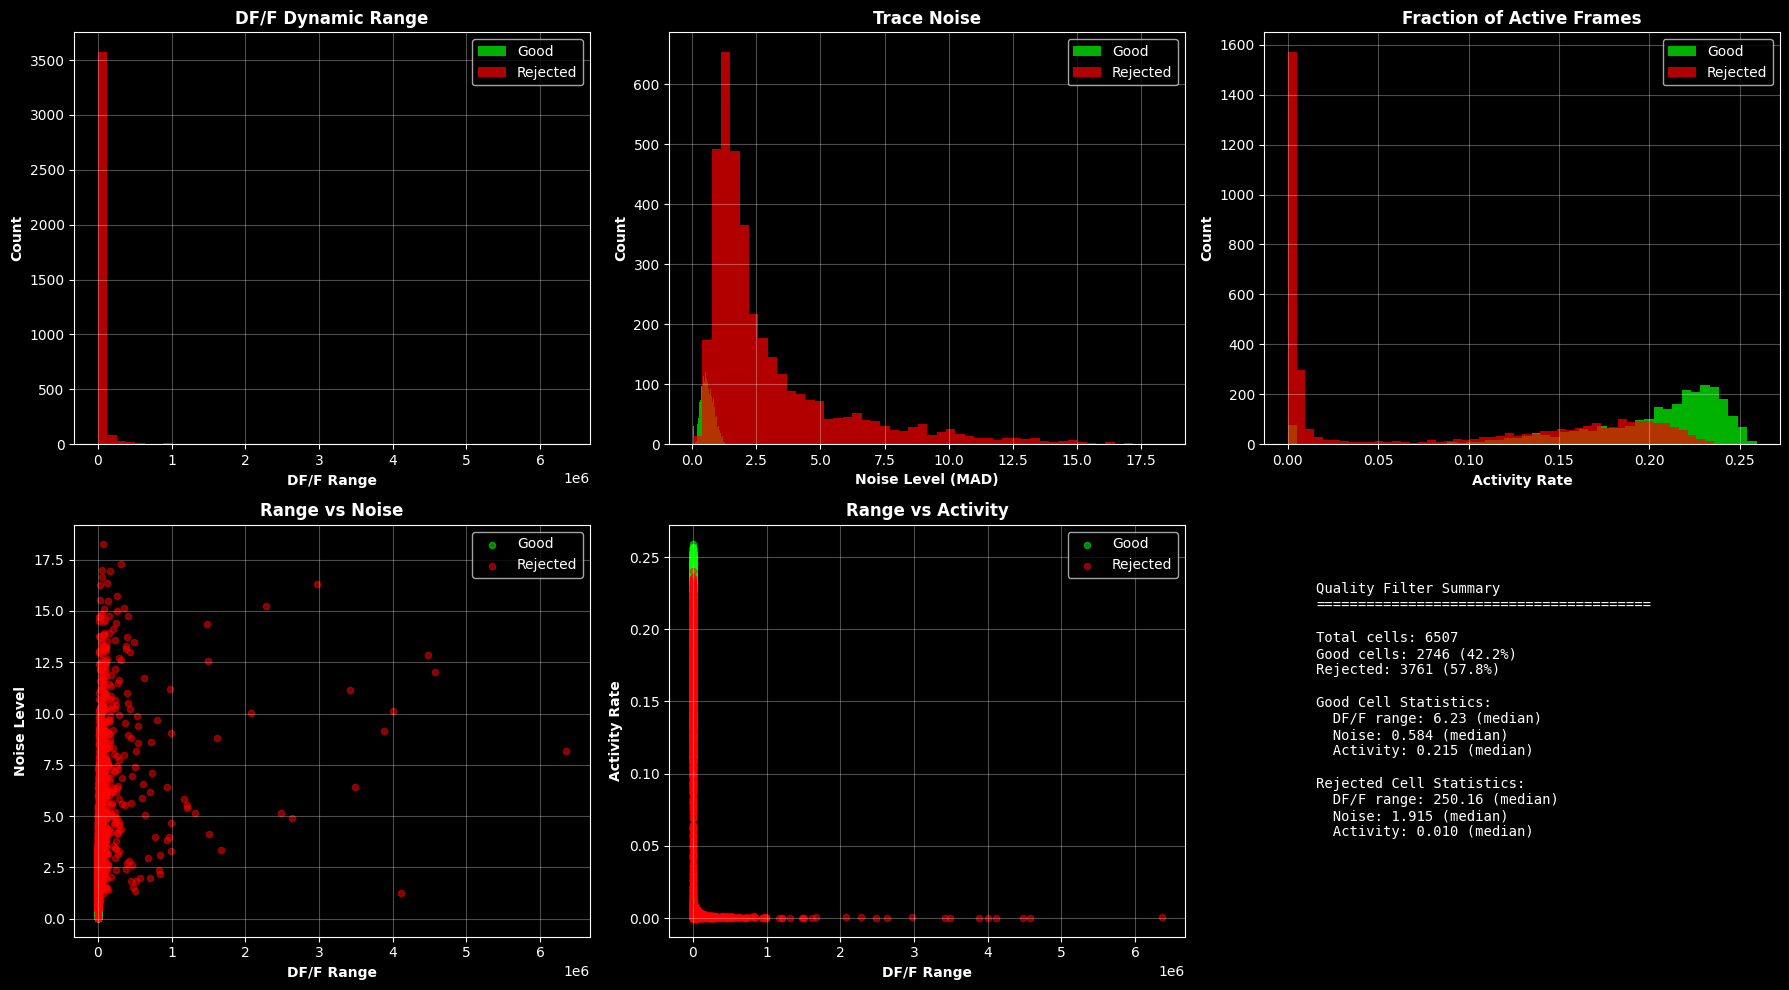

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor='black')

# DF/F range histogram
ax = axes[0, 0]
ax.hist(metrics['dff_range'][good_mask], bins=50, alpha=0.7, color='lime', label='Good')
ax.hist(metrics['dff_range'][~good_mask], bins=50, alpha=0.7, color='red', label='Rejected')
ax.set_xlabel('DF/F Range', fontweight='bold')
ax.set_ylabel('Count', fontweight='bold')
ax.set_title('DF/F Dynamic Range', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Noise histogram
ax = axes[0, 1]
ax.hist(metrics['noise'][good_mask], bins=50, alpha=0.7, color='lime', label='Good')
ax.hist(metrics['noise'][~good_mask], bins=50, alpha=0.7, color='red', label='Rejected')
ax.set_xlabel('Noise Level (MAD)', fontweight='bold')
ax.set_ylabel('Count', fontweight='bold')
ax.set_title('Trace Noise', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Activity rate
ax = axes[0, 2]
ax.hist(metrics['activity_rate'][good_mask], bins=50, alpha=0.7, color='lime', label='Good')
ax.hist(metrics['activity_rate'][~good_mask], bins=50, alpha=0.7, color='red', label='Rejected')
ax.set_xlabel('Activity Rate', fontweight='bold')
ax.set_ylabel('Count', fontweight='bold')
ax.set_title('Fraction of Active Frames', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Scatter: range vs noise
ax = axes[1, 0]
ax.scatter(metrics['dff_range'][good_mask], metrics['noise'][good_mask],
           c='lime', alpha=0.5, s=20, label='Good')
ax.scatter(metrics['dff_range'][~good_mask], metrics['noise'][~good_mask],
           c='red', alpha=0.5, s=20, label='Rejected')
ax.set_xlabel('DF/F Range', fontweight='bold')
ax.set_ylabel('Noise Level', fontweight='bold')
ax.set_title('Range vs Noise', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Scatter: range vs activity
ax = axes[1, 1]
ax.scatter(metrics['dff_range'][good_mask], metrics['activity_rate'][good_mask],
           c='lime', alpha=0.5, s=20, label='Good')
ax.scatter(metrics['dff_range'][~good_mask], metrics['activity_rate'][~good_mask],
           c='red', alpha=0.5, s=20, label='Rejected')
ax.set_xlabel('DF/F Range', fontweight='bold')
ax.set_ylabel('Activity Rate', fontweight='bold')
ax.set_title('Range vs Activity', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Summary text
ax = axes[1, 2]
ax.axis('off')
summary = f"""
Quality Filter Summary
{'='*40}

Total cells: {len(good_mask)}
Good cells: {good_mask.sum()} ({100*good_mask.sum()/len(good_mask):.1f}%)
Rejected: {(~good_mask).sum()} ({100*(~good_mask).sum()/len(good_mask):.1f}%)

Good Cell Statistics:
  DF/F range: {np.median(metrics['dff_range'][good_mask]):.2f} (median)
  Noise: {np.median(metrics['noise'][good_mask]):.3f} (median)
  Activity: {np.median(metrics['activity_rate'][good_mask]):.3f} (median)

Rejected Cell Statistics:
  DF/F range: {np.median(metrics['dff_range'][~good_mask]):.2f} (median)
  Noise: {np.median(metrics['noise'][~good_mask]):.3f} (median)
  Activity: {np.median(metrics['activity_rate'][~good_mask]):.3f} (median)
"""
ax.text(0.1, 0.9, summary, transform=ax.transAxes,
        fontsize=10, verticalalignment='top', family='monospace',
        color='white')

plt.tight_layout()
plt.show()

## 5. Advanced Trace Plotting Function

In [1]:
def plot_traces_advanced(
    F,
    dff,
    spks=None,
    fs=30.0,
    n_cells=10,
    selection_method='highest_activity',  # 'highest_activity', 'random', 'highest_snr', 'indices'
    cell_indices=None,
    time_range=None,  # (start_sec, end_sec) or None for full
    show_raw=True,
    show_dff=True,
    show_spikes=False,
    spacing_raw=None,  # Auto-compute if None
    spacing_dff=None,  # Auto-compute if None
    scale_bar_duration=10,  # seconds
    scale_bar_amplitude_pct=50,  # percent DF/F
    figsize=(20, 12),
):
    """
    Plot publication-quality fluorescence traces.

    Parameters
    ----------
    F : ndarray (n_cells, n_frames)
        Raw fluorescence
    dff : ndarray (n_cells, n_frames)
        DF/F traces
    spks : ndarray or None
        Deconvolved spikes
    fs : float
        Frame rate in Hz
    n_cells : int
        Number of cells to plot
    selection_method : str
        How to select cells: 'highest_activity', 'random', 'highest_snr', 'indices'
    cell_indices : list or None
        Specific cell indices to plot (used if selection_method='indices')
    time_range : tuple or None
        (start_sec, end_sec) to plot, or None for full recording
    show_raw : bool
        Show raw fluorescence traces
    show_dff : bool
        Show DF/F traces
    show_spikes : bool
        Overlay deconvolved spikes
    spacing_raw : float or None
        Vertical spacing for raw traces (auto if None)
    spacing_dff : float or None
        Vertical spacing for DF/F traces (auto if None)
    scale_bar_duration : float
        Duration of time scale bar in seconds
    scale_bar_amplitude_pct : float
        Amplitude of DF/F scale bar in percent
    figsize : tuple
        Figure size
    """
    # Select cells
    if selection_method == 'indices' and cell_indices is not None:
        selected_idx = np.array(cell_indices)[:n_cells]
    elif selection_method == 'highest_activity':
        activity = np.std(dff, axis=1)
        selected_idx = np.argsort(activity)[::-1][:n_cells]
    elif selection_method == 'highest_snr':
        signal = np.std(dff, axis=1)
        noise = np.median(np.abs(np.diff(dff, axis=1)), axis=1) / 0.6745
        snr = signal / (noise + 1e-6)
        selected_idx = np.argsort(snr)[::-1][:n_cells]
    elif selection_method == 'random':
        selected_idx = np.random.choice(F.shape[0], n_cells, replace=False)
    else:
        raise ValueError(f"Unknown selection method: {selection_method}")

    # Extract selected traces
    F_plot = F[selected_idx]
    dff_plot = dff[selected_idx]
    if spks is not None:
        spks_plot = spks[selected_idx]

    # Time axis
    time = np.arange(F_plot.shape[1]) / fs

    # Apply time range
    if time_range is not None:
        start_sec, end_sec = time_range
        start_idx = int(start_sec * fs)
        end_idx = int(end_sec * fs)
        time = time[start_idx:end_idx]
        F_plot = F_plot[:, start_idx:end_idx]
        dff_plot = dff_plot[:, start_idx:end_idx]
        if spks is not None:
            spks_plot = spks_plot[:, start_idx:end_idx]

    # Auto-compute spacing
    if spacing_raw is None:
        spacing_raw = np.percentile(np.ptp(F_plot, axis=1), 75) * 1.5
    if spacing_dff is None:
        spacing_dff = np.percentile(np.ptp(dff_plot, axis=1), 75) * 1.5

    # Create figure
    n_panels = int(show_raw) + int(show_dff)
    fig, axes = plt.subplots(n_panels, 1, figsize=figsize, facecolor='black')
    if n_panels == 1:
        axes = [axes]

    panel_idx = 0

    # Plot raw fluorescence
    if show_raw:
        ax = axes[panel_idx]
        for i, idx in enumerate(selected_idx):
            offset = i * spacing_raw
            ax.plot(time, F_plot[i] + offset, linewidth=0.5, color='cyan', alpha=0.8)
            ax.text(time[0], offset, f'Cell {idx}', fontsize=8, va='bottom', color='white')

        ax.set_xlabel('Time (s)', fontweight='bold', fontsize=12)
        ax.set_ylabel('Raw Fluorescence (a.u.)', fontweight='bold', fontsize=12)
        ax.set_title(f'Raw Fluorescence Traces (n={n_cells})', fontweight='bold', fontsize=14)
        ax.spines['left'].set_visible(False)
        ax.set_yticks([])
        ax.grid(axis='x', alpha=0.3)

        # Scale bar for raw
        x_scale = time[-1] - scale_bar_duration
        y_scale = -spacing_raw * 0.5
        ax.plot([x_scale, x_scale + scale_bar_duration], [y_scale, y_scale],
                'w-', linewidth=3)
        ax.text(x_scale + scale_bar_duration/2, y_scale - spacing_raw*0.2,
                f'{scale_bar_duration}s', ha='center', color='white', fontweight='bold')

        panel_idx += 1

    # Plot DF/F
    if show_dff:
        ax = axes[panel_idx]
        for i, idx in enumerate(selected_idx):
            offset = i * spacing_dff
            ax.plot(time, dff_plot[i] + offset, linewidth=0.5, color='lime', alpha=0.8)

            # Overlay spikes if requested
            if show_spikes and spks is not None:
                spike_times = time[spks_plot[i] > 0.5]
                spike_heights = dff_plot[i][spks_plot[i] > 0.5] + offset
                ax.scatter(spike_times, spike_heights, c='red', s=10, alpha=0.6, marker='|')

            ax.text(time[0], offset, f'Cell {idx}', fontsize=8, va='bottom', color='white')

        ax.set_xlabel('Time (s)', fontweight='bold', fontsize=12)
        ax.set_ylabel('ΔF/F', fontweight='bold', fontsize=12)
        title = f'ΔF/F Traces (n={n_cells})'
        if show_spikes:
            title += ' + Spikes (red)'
        ax.set_title(title, fontweight='bold', fontsize=14)
        ax.spines['left'].set_visible(False)
        ax.set_yticks([])
        ax.grid(axis='x', alpha=0.3)

        # Scale bars for DF/F
        x_scale = time[-1] - scale_bar_duration
        y_scale = -spacing_dff * 0.5

        # Time scale bar
        ax.plot([x_scale, x_scale + scale_bar_duration], [y_scale, y_scale],
                'w-', linewidth=3)
        ax.text(x_scale + scale_bar_duration/2, y_scale - spacing_dff*0.15,
                f'{scale_bar_duration}s', ha='center', color='white', fontweight='bold')

        # Amplitude scale bar
        amplitude_scale = scale_bar_amplitude_pct / 100.0
        ax.plot([x_scale, x_scale], [y_scale, y_scale + amplitude_scale],
                'w-', linewidth=3)
        ax.text(x_scale - scale_bar_duration*0.05, y_scale + amplitude_scale/2,
                f'{scale_bar_amplitude_pct}%', ha='right', va='center',
                color='white', fontweight='bold')

    plt.tight_layout()
    return fig, selected_idx

## 6. Test Different Visualizations

Plotting highest activity cells...


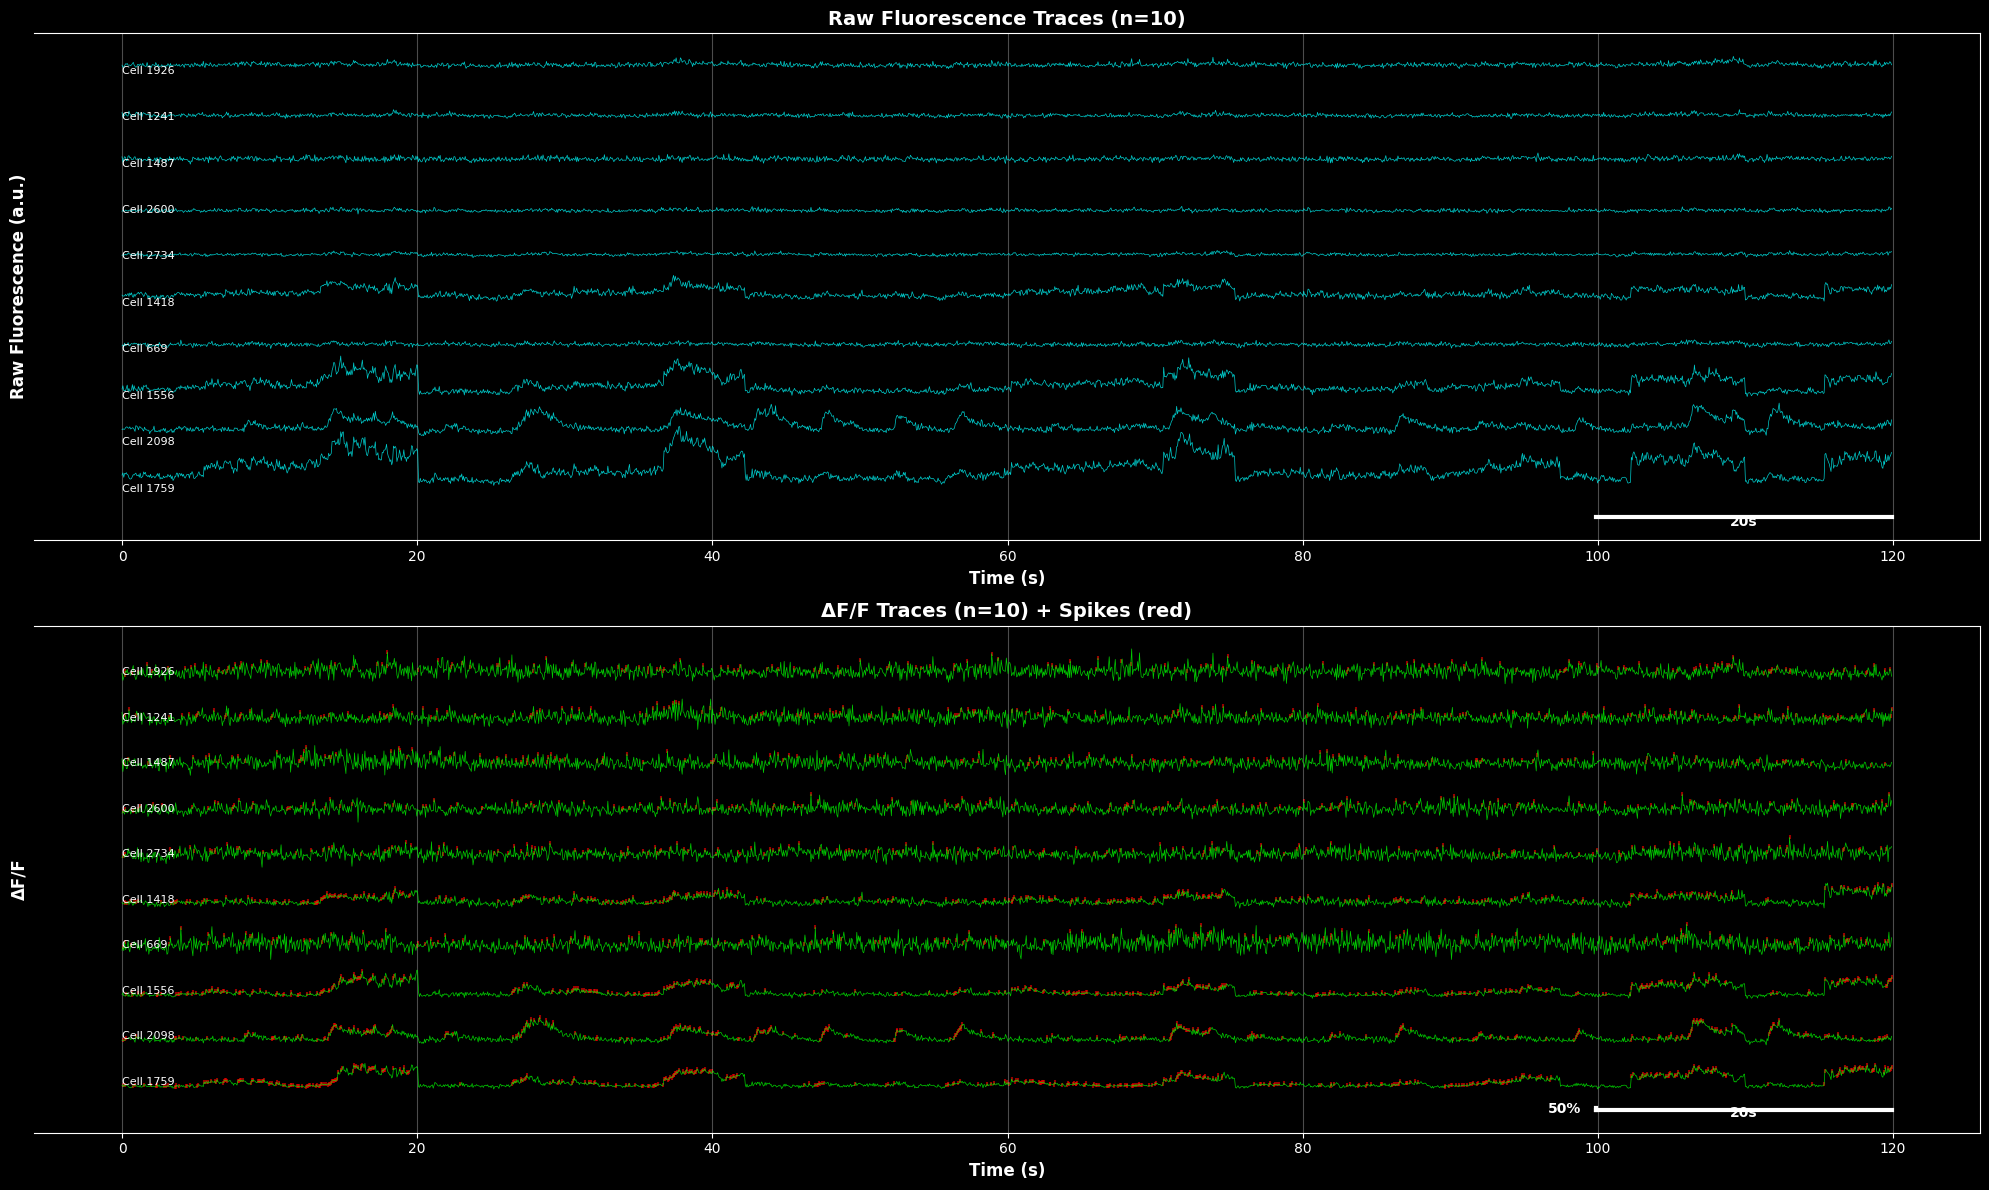

Selected cells: [1759 2098 1556  669 1418 2734 2600 1487 1241 1926]


In [9]:
# Example 1: Show highest activity cells with both raw and DF/F
print("Plotting highest activity cells...")
fig, selected = plot_traces_advanced(
    F_good,
    dff_good,
    spks=spks_good,
    fs=fs,
    n_cells=10,
    selection_method='highest_activity',
    time_range=(0, 120),  # First 2 minutes
    show_raw=True,
    show_dff=True,
    show_spikes=True,
    scale_bar_duration=20,
    scale_bar_amplitude_pct=50,
)
plt.savefig(merged_path / 'traces_highest_activity.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()
print(f"Selected cells: {selected}")

Plotting highest SNR cells (DF/F only)...


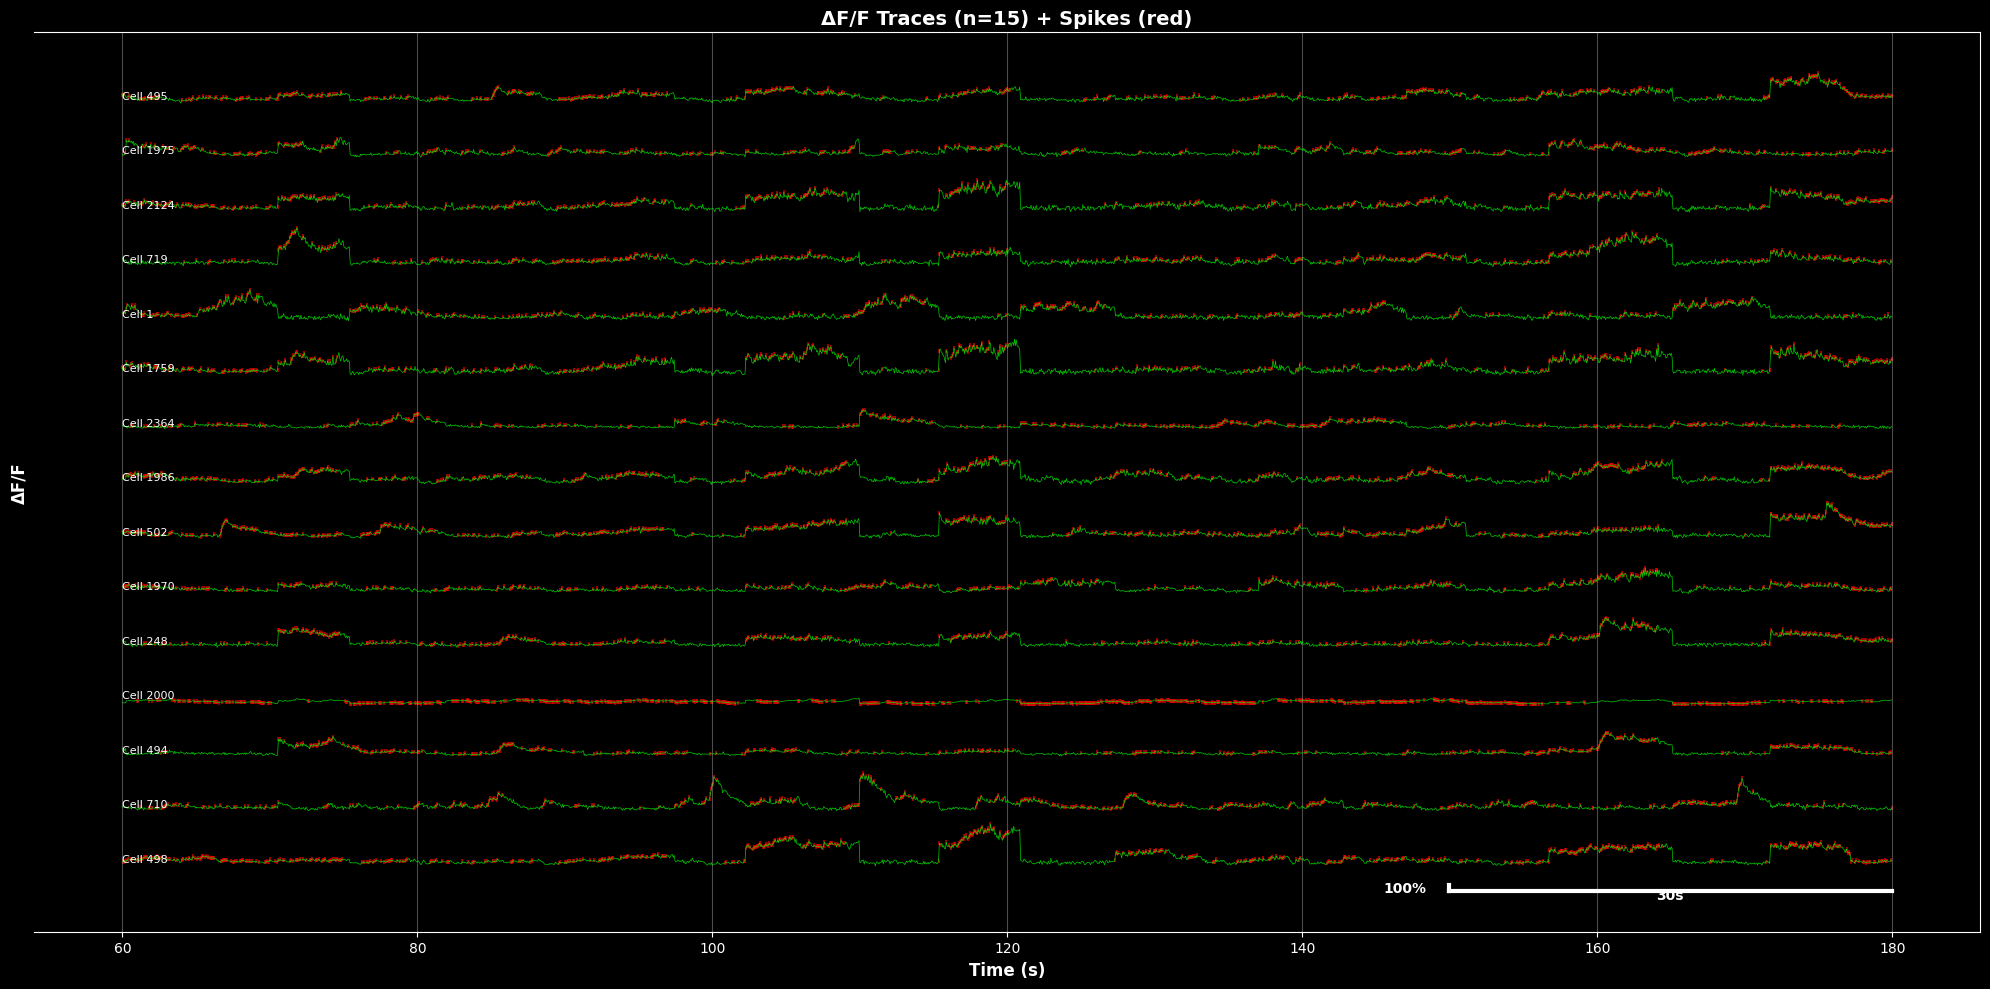

Selected cells: [ 498  710  494 2000  248 1970  502 1986 2364 1759    1  719 2124 1975
  495]


In [10]:
# Example 2: DF/F only, highest SNR cells
print("Plotting highest SNR cells (DF/F only)...")
fig, selected = plot_traces_advanced(
    F_good,
    dff_good,
    spks=spks_good,
    fs=fs,
    n_cells=15,
    selection_method='highest_snr',
    time_range=(60, 180),  # Minute 1-3
    show_raw=False,
    show_dff=True,
    show_spikes=True,
    scale_bar_duration=30,
    scale_bar_amplitude_pct=100,
    figsize=(20, 10),
)
plt.savefig(merged_path / 'traces_highest_snr.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()
print(f"Selected cells: {selected}")

Comparing baseline estimation methods...
Auto-computed window size: 341 frames (20.0s) based on tau=2.0s
Auto-computed window size: 341 frames (20.0s) based on tau=2.0s
Auto-computed window size: 341 frames (20.0s) based on tau=2.0s


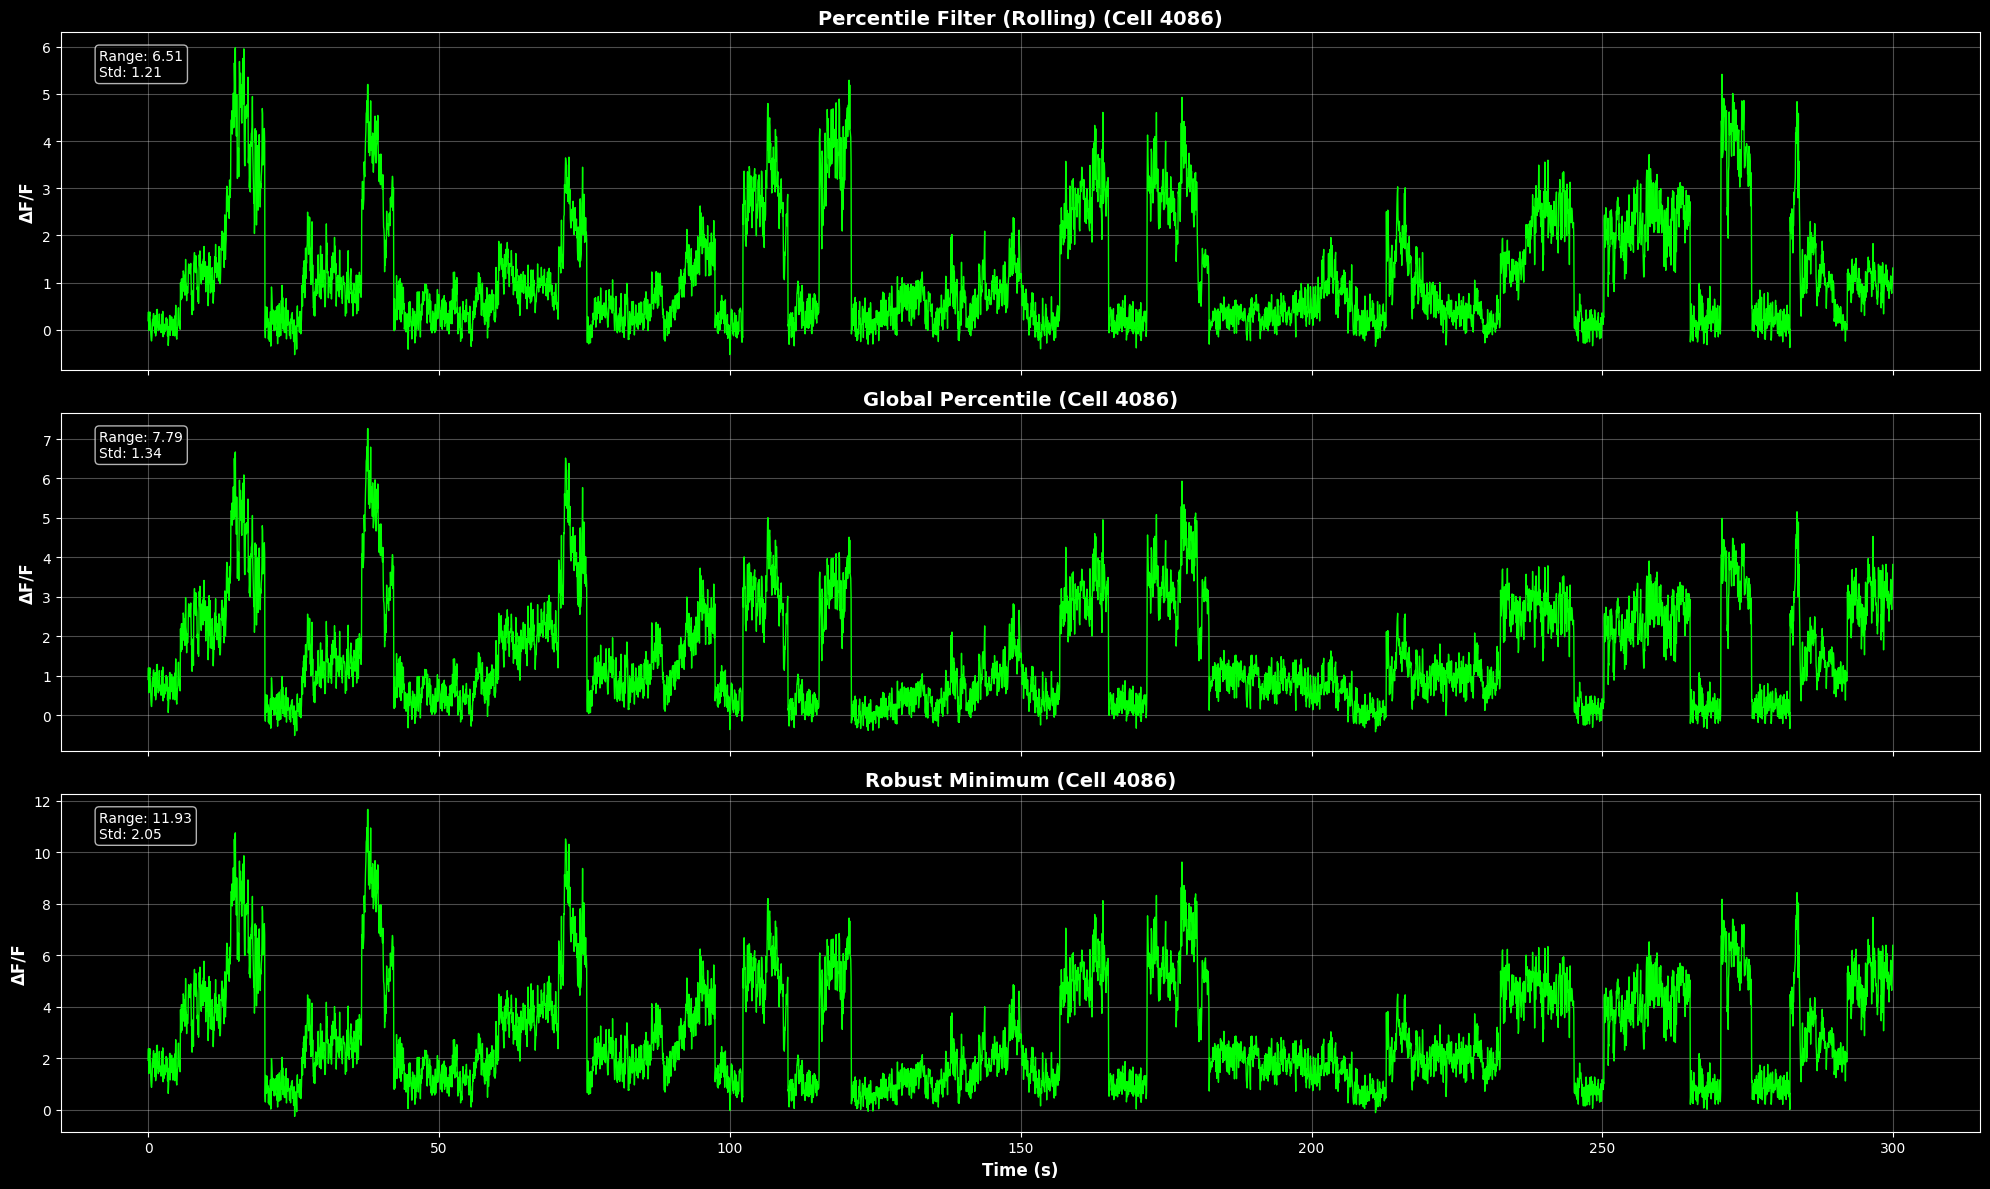

In [11]:
# Example 3: Compare baseline methods side-by-side
print("Comparing baseline estimation methods...")

# Select one high-quality cell
activity = np.std(dff_good, axis=1)
best_cell_idx = np.argmax(activity)
cell_idx_original = np.where(good_mask)[0][best_cell_idx]

# Get traces for this cell
F_cell = F_accepted[cell_idx_original:cell_idx_original+1]
Fneu_cell = Fneu_accepted[cell_idx_original:cell_idx_original+1]

# Compute with different methods
dff_pf_cell, _ = compute_dff(F_cell, Fneu_cell, baseline_method='percentile_filter',
                              percentile=8, fs=fs, tau_decay=2.0)
dff_global_cell, _ = compute_dff(F_cell, Fneu_cell, baseline_method='percentile_global',
                                  percentile=20, fs=fs)
dff_robust_cell, _ = compute_dff(F_cell, Fneu_cell, baseline_method='robust_minimum',
                                  percentile=10, fs=fs)

# Plot comparison
fig, axes = plt.subplots(3, 1, figsize=(20, 12), facecolor='black', sharex=True)
time = np.arange(F_cell.shape[1]) / fs
time_range = (0, 300)  # First 5 minutes
start_idx = int(time_range[0] * fs)
end_idx = int(time_range[1] * fs)
time_plot = time[start_idx:end_idx]

methods = [
    ('Percentile Filter (Rolling)', dff_pf_cell),
    ('Global Percentile', dff_global_cell),
    ('Robust Minimum', dff_robust_cell),
]

for ax, (name, dff_method) in zip(axes, methods):
    ax.plot(time_plot, dff_method[0, start_idx:end_idx], linewidth=1, color='lime')
    ax.set_ylabel('ΔF/F', fontweight='bold', fontsize=12)
    ax.set_title(f'{name} (Cell {cell_idx_original})', fontweight='bold', fontsize=14)
    ax.grid(alpha=0.3)

    # Add statistics
    dff_range = np.ptp(dff_method[0, start_idx:end_idx])
    dff_std = np.std(dff_method[0, start_idx:end_idx])
    ax.text(0.02, 0.95, f'Range: {dff_range:.2f}\nStd: {dff_std:.2f}',
            transform=ax.transAxes, va='top', fontsize=10, color='white',
            bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

axes[-1].set_xlabel('Time (s)', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(merged_path / 'baseline_method_comparison.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()

## 8. Why is lbm_suite2p_python.plot_traces() ineffective?

Analyzing the existing implementation in zplane.py

Testing lbm_suite2p_python.plot_traces()...
Data shape: (2746, 58825)


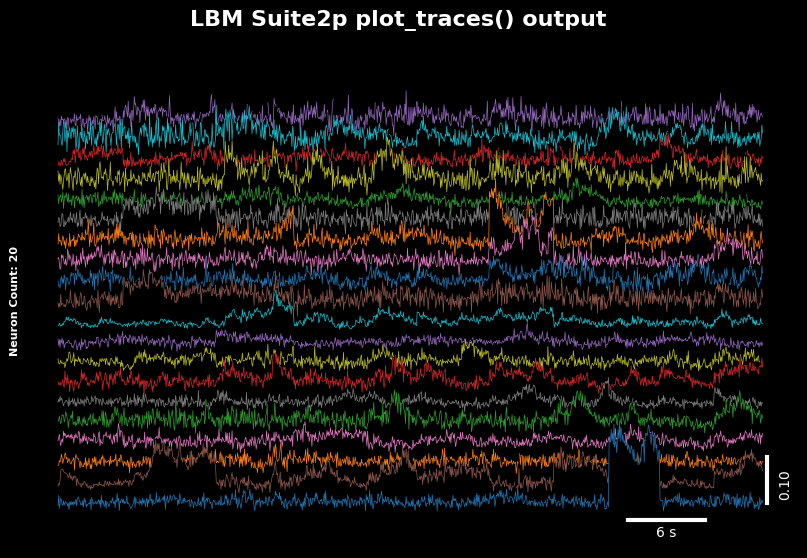

In [24]:
# Import and test the existing plot_traces function
import sys
sys.path.insert(0, str(Path.cwd().parent.parent))
from lbm_suite2p_python.zplane import plot_traces

# Test with current data
print("Testing lbm_suite2p_python.plot_traces()...")
print(f"Data shape: {dff_good.shape}")

# Call the function to see what happens
plot_traces(
    dff_good,
    cell_indices=None,
    fps=fs,
    num_neurons=20,
    window=60,
    title="LBM Suite2p plot_traces() output",
    # save_path=merged_path / "original_plot_traces.png"
)

## 9. plot_traces_v2: Fixed version of lbm_suite2p_python.plot_traces()

Uses the composite masking approach but with:
- Fixed scale bars that match the actual display
- Support for cell_indices or most active selection
- Works with 1 or more traces

In [ ]:
def plot_traces_v2(
    f,
    dff=None,
    fps=17.0,
    num_neurons=20,
    cell_indices=None,
    window=60,
    title="",
    offset=None,
    lw=0.5,
    cmap="tab10",
    save_path=None,
    figsize=(10, 6),
    scale_bar_label="50% ΔF/F₀",  # User-supplied string label for scale bar
):
    """
    Fixed version of lbm_suite2p_python.plot_traces with proper scale bars.

    Uses composite masking approach but fixes:
    - Scale bar is 10% of figure height
    - User supplies the scale bar label as a string
    - Selects most active cells by default
    - Supports cell_indices override
    - Works with 1+ traces
    - Tight spacing (no wasted space)
    """
    from lbm_suite2p_python.zplane import get_color_permutation, AnchoredHScaleBar, AnchoredVScaleBar

    if isinstance(f, dict):
        raise ValueError("f must be numpy array")

    n_timepoints = f.shape[-1]
    data_time = np.arange(n_timepoints) / fps
    current_frame = min(int(window * fps), n_timepoints - 1)

    # Select cells: use indices if provided, otherwise pick most active
    if cell_indices is not None:
        indices = np.array(cell_indices)
        if indices.dtype == bool:
            indices = np.where(indices)[0]
        displayed_neurons = len(indices)
    else:
        # Select most active by standard deviation
        if dff is not None:
            activity = np.std(dff, axis=1)
        else:
            activity = np.std(f, axis=1)
        most_active = np.argsort(activity)[::-1]
        displayed_neurons = min(num_neurons, f.shape[0])
        indices = most_active[:displayed_neurons]

    if len(indices) == 0:
        print("No cells to plot")
        return None

    # Calculate offset
    if offset is None:
        p10 = np.percentile(f[indices, :current_frame + 1], 10, axis=1)
        p90 = np.percentile(f[indices, :current_frame + 1], 90, axis=1)
        offset = np.median(p90 - p10) * 1.2
        min_offset = np.percentile(p90 - p10, 75) * 0.8
        offset = max(offset, min_offset, 1e-6)

    # Colors
    cmap_inst = plt.get_cmap(cmap)
    colors = cmap_inst(np.linspace(0, 1, displayed_neurons))
    perm = get_color_permutation(displayed_neurons)
    colors = colors[perm]

    # Build composite array (hide overlapping parts)
    composite = np.full_like(f[indices, :current_frame + 1], np.nan)
    for i in range(displayed_neurons):
        trace = f[indices[i], :current_frame + 1]
        baseline = np.percentile(trace, 8)
        shifted = (trace - baseline) + i * offset
        if i == 0:
            composite[i] = shifted
        else:
            below = np.nanmax(composite[:i], axis=0)
            masked = np.where(shifted > below, shifted, np.nan)
            composite[i] = masked

    # Plot with tight layout
    fig, ax = plt.subplots(figsize=figsize, facecolor='black')
    ax.set_facecolor('black')
    ax.tick_params(axis='x', which='both', labelbottom=False, length=0, colors='white')
    ax.tick_params(axis='y', which='both', labelleft=False, length=0, colors='white')
    for spine in ax.spines.values():
        spine.set_visible(False)

    for i in range(displayed_neurons):
        ax.plot(
            data_time[:current_frame + 1],
            composite[i],
            color=colors[i],
            lw=lw,
            zorder=-i,
        )

    # Calculate y-range
    all_shifted = [
        (f[indices[i], :current_frame + 1] - np.percentile(f[indices[i], :current_frame + 1], 8))
        + i * offset
        for i in range(displayed_neurons)
    ]
    all_y = np.concatenate(all_shifted)
    y_min, y_max = np.min(all_y), np.max(all_y)

    # Set tight y-limits (minimal padding)
    y_padding = (y_max - y_min) * 0.02
    ax.set_ylim(y_min - y_padding, y_max + y_padding)

    # Time scale bar
    time_bar_length = 0.1 * window
    if time_bar_length < 60:
        time_label = f"{time_bar_length:.0f} s"
    elif time_bar_length < 3600:
        time_label = f"{time_bar_length / 60:.0f} min"
    else:
        time_label = f"{time_bar_length / 3600:.1f} hr"

    linekw = dict(color='white', linewidth=3)
    hsb = AnchoredHScaleBar(
        size=0.1,
        label=time_label,
        loc=4,
        frameon=False,
        pad=0.6,
        sep=4,
        linekw=linekw,
        ax=ax,
    )
    hsb.set_bbox_to_anchor((0.9, -0.05), transform=ax.transAxes)
    hsb.txt._text.set_color('white')
    ax.add_artist(hsb)

    # Vertical scale bar is 10% of figure height
    vertical_bar_height_axis = 0.10

    vsb = AnchoredVScaleBar(
        height=vertical_bar_height_axis,
        label=scale_bar_label,
        loc='lower right',
        frameon=False,
        pad=-0.1,
        sep=4,
        linekw=linekw,
        ax=ax,
        spacer_width=0,
    )
    vsb.set_bbox_to_anchor((1.00, 0.05), transform=ax.transAxes)
    vsb.txt._text.set_color('white')
    ax.add_artist(vsb)

    if title:
        fig.suptitle(title, fontsize=16, fontweight='bold', color='white', y=0.98)

    ax.set_ylabel(
        f"Neuron Count: {displayed_neurons}",
        fontsize=8,
        fontweight='bold',
        color='white',
        labelpad=2,
    )

    # Tight layout to minimize wasted space
    plt.tight_layout(rect=[0, 0.02, 1, 0.96] if title else [0, 0.02, 1, 1])

    if save_path:
        plt.savefig(save_path, dpi=200, facecolor=fig.get_facecolor(), bbox_inches='tight')
        plt.close(fig)
    else:
        plt.show()

    return fig

In [ ]:
# Example 1: Most active cells with custom label
print("Example 1: Most active 20 cells with custom scale bar label")
plot_traces_v2(
    dff_good,
    dff=dff_good,
    fps=fs,
    num_neurons=20,
    window=60,
    scale_bar_label="50% ΔF/F₀",
    title="Most Active Cells",
    # save_path=merged_path / "traces_v2_example1.png",
    figsize=(12, 8),
)
print("Done")

In [ ]:
# Example 2: Specific cell indices with percentage units
print("Example 2: Specific cell indices with percentage ΔF/F")
plot_traces_v2(
    dff_good,
    dff=dff_good,
    fps=fs,
    cell_indices=[0, 10, 50, 100, 200],
    window=120,
    scale_bar_label="100%",
    title="Selected Cells",
    # save_path=merged_path / "traces_v2_example2.png",
    figsize=(14, 6),
)
print("Done")

In [ ]:
# Example 3: Raw fluorescence with arbitrary units
print("Example 3: Raw fluorescence traces")
plot_traces_v2(
    F_good,
    fps=fs,
    num_neurons=15,
    window=90,
    scale_bar_label="500 a.u.",
    title="Raw Fluorescence Traces",
    # save_path=merged_path / "traces_v2_example3.png",
    figsize=(12, 7),
)
print("Done")

In [ ]:
# Example 4: Single cell with simple numeric label
print("Example 4: Single most active cell, long time window")
plot_traces_v2(
    dff_good,
    dff=dff_good,
    fps=fs,
    num_neurons=1,
    window=300,
    scale_bar_label="0.5",
    title="Single Cell (5 min window)",
    # save_path=merged_path / "traces_v2_example4.png",
    figsize=(18, 4),
)
print("Done")